In [43]:
import pyepo
from pyepo import data
from matplotlib import pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader
from torch import nn

In [56]:
#Generate Data
m = 20 #items
n = 2000 #samples
p = 5 #features
deg = 4 #polynomial degree
dim = 1 #dimension of knapsack
noise_width = 0.5 #noise half-width
caps = [20] * dim #capacity
weights, x, c = pyepo.data.knapsack.genData(n, p, m, deg=deg, dim=dim, noise_width=noise_width)
caps = [int(0.4 * w) for w in weights.sum(axis=1)]

#Split Data Into Train / Test
x_train, x_test, c_train, c_test = train_test_split(x, c, test_size= int(n *.9))

In [57]:
#Create Optimization Model Datasets, and Data Loaders
optmodel = pyepo.model.grb.knapsackModel(weights, caps)

dataset_train = pyepo.data.dataset.optDataset(optmodel, x_train, c_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, x_test, c_test)

batch_size = 64
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Optimizing for optDataset...


100%|██████████| 200/200 [00:00<00:00, 482.71it/s]

Optimizing for optDataset...



100%|██████████| 1800/1800 [00:04<00:00, 400.07it/s]


In [58]:
#Define Models

#Linear Regression Model
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(p, m)

    def forward(self, x):
        out = self.linear(x)
        return out

#MLP Model
class MLP(nn.Module):
    def __init__(self, num_feat, hidden, num_item):
        super(MLP, self).__init__()
        self.l1 = nn.Linear(num_feat, hidden)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden, num_item)
        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

In [59]:
def trainModel(model, criterion, name, epochs=40, lr=1e-1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loss_log, train_regret_log = [], []
    test_loss_log, test_regret_log = [], []
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        temp_loss = []
        for data in loader_train:
            x, c, w, z = data
            cp = model(x)
            
            loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            temp_loss.append(loss.item())

        # Calculate Training Metrics (Once per epoch)
        train_loss_log.append(np.mean(temp_loss))
        train_regret_log.append(pyepo.metric.regret(model, optmodel, loader_train))

        # --- TESTING ---
        model.eval() # Important for consistency
        temp_loss = []
        with torch.no_grad():
            for data in loader_test:
                x, c, w, z = data
                cp = model(x)
                loss = criterion(cp, c, w, z) if name == "SPO+" else criterion(cp, c)
                temp_loss.append(loss.item())
        
        # Calculate Testing Metrics (Once per epoch)
        test_loss_log.append(np.mean(temp_loss))
        test_regret_log.append(pyepo.metric.regret(model, optmodel, loader_test))

        if epoch % 10 == 0:
            print(f'Epoch:{epoch} Loss Type:{name}')
            print(f'Train Loss {train_loss_log[-1]:.2f} Test Loss {test_loss_log[-1]:.2f}')
            print(f'Train Regret {train_regret_log[-1] *100:.2f}% Test Regret {test_regret_log[-1]*100:.2f}%')

    return train_loss_log, test_loss_log, train_regret_log, test_regret_log

In [60]:
def plotLearningCurves(train_loss, test_loss, train_regret, test_regret, name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    epochs = range(len(train_loss))

    # --- Plot 1: Loss (Prediction Error) ---
    ax[0].plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
    ax[0].plot(epochs, test_loss, label='Test Loss', color='lightblue', linestyle='--')
    ax[0].set_title(f'{name} Loss Trajectory')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- Plot 2: Regret (Decision Error) ---
    # We multiply by 100 to show percentage
    ax[1].plot(epochs, [r * 100 for r in train_regret], label='Train Regret', color='green', lw=2)
    ax[1].plot(epochs, [r * 100 for r in test_regret], label='Test Regret', color='lightgreen', linestyle='--')
    ax[1].set_title(f'{name} Regret Trajectory')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Regret (%)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch:0 Loss Type:MSE
Train Loss 25.59 Test Loss 9.60
Train Regret 17.16% Test Regret 17.24%
Epoch:10 Loss Type:MSE
Train Loss 2.66 Test Loss 3.16
Train Regret 4.53% Test Regret 4.75%
Epoch:20 Loss Type:MSE
Train Loss 2.55 Test Loss 2.96
Train Regret 3.97% Test Regret 4.70%
Epoch:30 Loss Type:MSE
Train Loss 2.14 Test Loss 2.84
Train Regret 3.73% Test Regret 4.48%
Epoch:40 Loss Type:MSE
Train Loss 2.47 Test Loss 2.78
Train Regret 3.45% Test Regret 4.56%


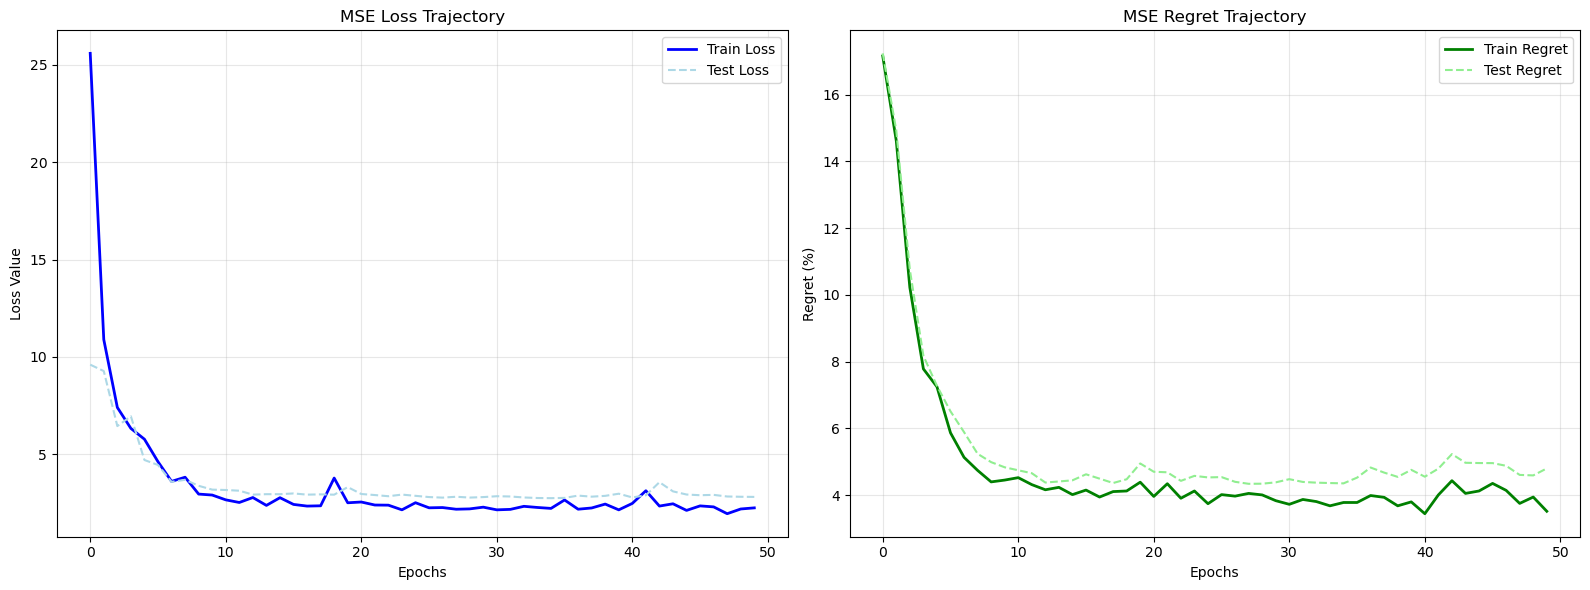

In [61]:
model = MLP(p, 16, m)
mse = nn.MSELoss()
logs = trainModel(model, mse, "MSE", epochs=50)
plotLearningCurves(*logs, name="MSE")

In [ ]:
model = MLP(p, 16, m)
spop = pyepo.func.SPOPlus(optmodel, processes=1)
logs = trainModel(model, spop, "SPO+", epochs=50)
plotLearningCurves(*logs, name="SPO+")

Num of cores: 1
Epoch:0 Loss Type:SPO+
Train Loss 43.05 Test Loss 25.35
Train Regret 15.90% Test Regret 16.73%
Epoch:10 Loss Type:SPO+
Train Loss 10.04 Test Loss 11.15
Train Regret 3.63% Test Regret 4.74%
Epoch:20 Loss Type:SPO+
Train Loss 9.58 Test Loss 11.35
Train Regret 3.38% Test Regret 4.80%
Epoch:30 Loss Type:SPO+
Train Loss 7.94 Test Loss 11.13
Train Regret 3.50% Test Regret 4.73%
